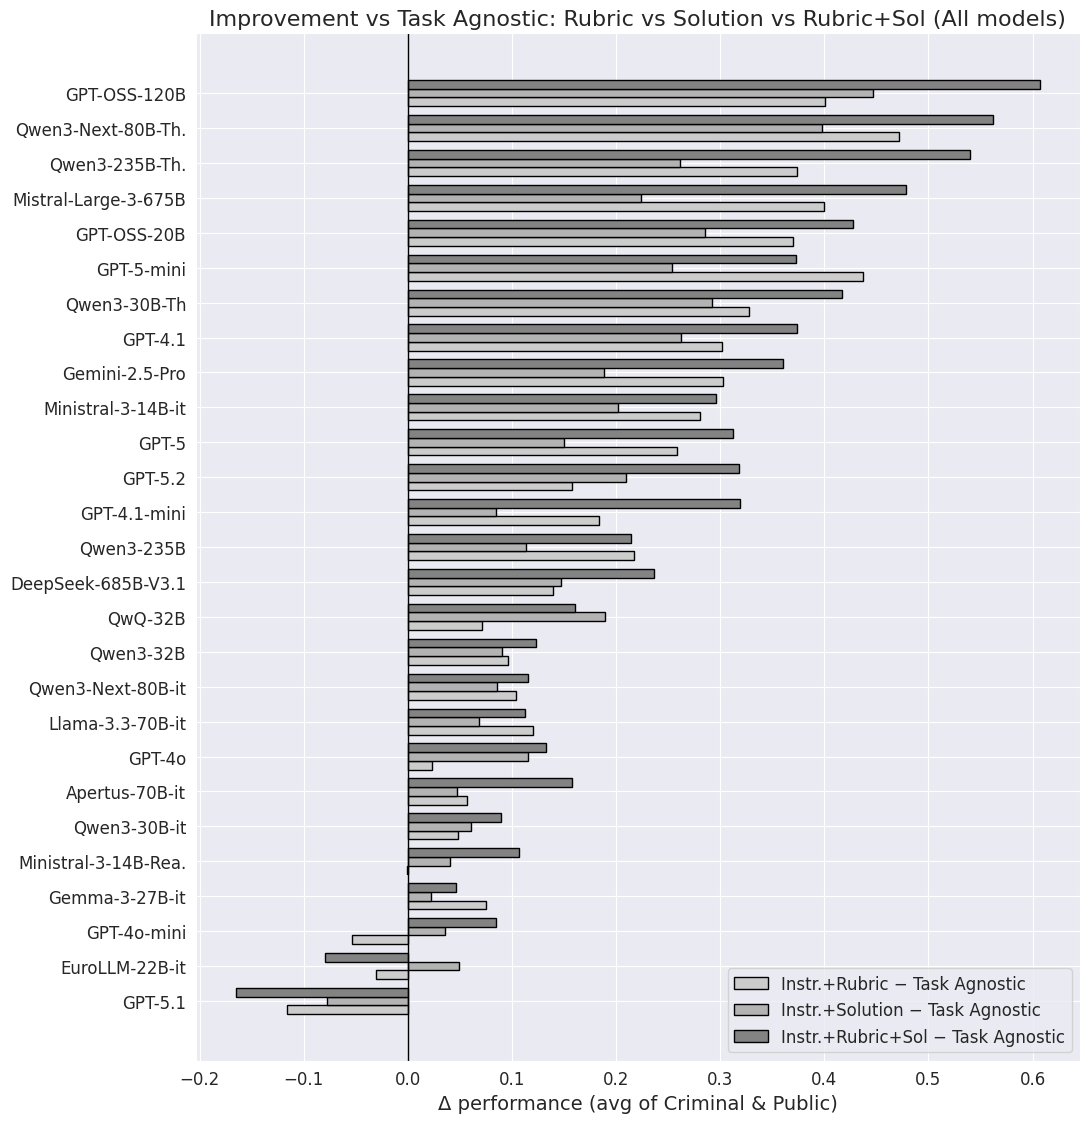

In [1]:
###
### Improvements from task agnostict to Instruction+Rubric vs Instruction+Solution vs Instruction+Rubric+Solution
### 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("darkgrid")


rows = []

def add(group, model,
        task_c, task_p,
        rub_c, rub_p,
        sol_c, sol_p,
        rubsol_c, rubsol_p):
    rows.append({
        "group": group,
        "model": model,

        "task_criminal": task_c, "task_public": task_p,
        "rubric_criminal": rub_c, "rubric_public": rub_p,
        "solution_criminal": sol_c, "solution_public": sol_p,
        "rubsol_criminal": rubsol_c, "rubsol_public": rubsol_p,
    })

# -----------------------------
# Reasoning
# -----------------------------
add("Reasoning", "GPT-5.2",               0.311,  0.356,  0.298, 0.685, 0.465, 0.621, 0.431, 0.873)
add("Reasoning", "GPT-5",                 0.309,  0.576,  0.557, 0.846, 0.392, 0.793, 0.599, 0.911)
add("Reasoning", "GPT-5.1",               0.181,  0.596,  0.145, 0.399, 0.151, 0.470, 0.086, 0.361)
add("Reasoning", "Gemini-2.5-Pro",        0.161,  0.568,  0.475, 0.860, 0.430, 0.676, 0.565, 0.884)
add("Reasoning", "GPT-5-mini",            0.097,  0.224,  0.499, 0.697, 0.270, 0.558, 0.425, 0.641)
add("Reasoning", "DeepSeek-685B-V3.1",    0.088,  0.501,  0.287, 0.581, 0.283, 0.600, 0.277, 0.785)
add("Reasoning", "GPT-OSS-20B",           0.065,  0.073,  0.250, 0.628, 0.171, 0.538, 0.282, 0.712)
add("Reasoning", "Qwen3-Next-80B-Th.",    0.050, -0.049,  0.309, 0.635, 0.269, 0.527, 0.336, 0.789)
add("Reasoning", "Ministral-3-14B-Rea.",   0.030,  0.036,  0.072,-0.007, 0.052, 0.095,-0.008, 0.287)
add("Reasoning", "Qwen3-235B-Th.",        0.008,  0.153,  0.305, 0.604, 0.234, 0.450, 0.453, 0.787)
add("Reasoning", "Qwen3-32B",             0.000,  0.006,  0.042, 0.156, 0.065, 0.122, 0.117, 0.136)
add("Reasoning", "Qwen3-30B-Th",         -0.007, -0.015,  0.129, 0.505, 0.101, 0.461, 0.306, 0.506)
add("Reasoning", "QwQ-32B",              -0.008,  0.080,  0.068, 0.146, 0.083, 0.367, 0.050, 0.343)
add("Reasoning", "GPT-OSS-120B",         -0.032, -0.085,  0.284, 0.400, 0.307, 0.469, 0.353, 0.744)

# -----------------------------
# Non-Reasoning
# -----------------------------
add("Non-Reasoning", "Mistral-Large-3-675B",      0.067, 0.113,  0.270, 0.709, 0.205, 0.423, 0.347, 0.790)
add("Non-Reasoning", "GPT-4o",             0.063, 0.283,  0.114, 0.279, 0.168, 0.409, 0.145, 0.466)
add("Non-Reasoning", "GPT-4.1",            0.052, 0.338,  0.405, 0.589, 0.236, 0.678, 0.478, 0.659)
add("Non-Reasoning", "Ministral-3-14B-it",  0.022, 0.013,  0.058, 0.538, 0.064, 0.375, 0.113, 0.514)
add("Non-Reasoning", "Gemma-3-27B-it",     0.015, 0.011,  0.124, 0.053, 0.011, 0.060, 0.075, 0.044)
add("Non-Reasoning", "GPT-4.1-mini",       0.013, 0.096,  0.156, 0.321, 0.103, 0.176, 0.149, 0.598)
add("Non-Reasoning", "GPT-4o-mini",        0.013, 0.037, -0.075, 0.017, 0.087, 0.034, 0.107, 0.113)
add("Non-Reasoning", "Qwen3-Next-80B-it",  0.010, 0.074,  0.030, 0.262, 0.056, 0.200, 0.052, 0.263)
add("Non-Reasoning", "Qwen3-235B",         0.007, 0.026,  0.012, 0.456, 0.054, 0.206, 0.096, 0.366)
add("Non-Reasoning", "Qwen3-30B-it",       0.006, 0.001,  0.052, 0.052, 0.036, 0.092, 0.082, 0.104)
add("Non-Reasoning", "Apertus-70B-it",     0.005,-0.004,  0.117,-0.002, 0.058, 0.037, 0.002, 0.314)
add("Non-Reasoning", "Llama-3.3-70B-it",   0.004, 0.005,  0.074, 0.175, 0.027, 0.118, 0.062, 0.172)
add("Non-Reasoning", "EuroLLM-22B-it",    -0.015, 0.019, -0.007,-0.050, 0.037, 0.066,-0.124,-0.031)

df = pd.DataFrame(rows)

# display(df)

# ============================================================
# 2) Aggregate performance: average of Criminal & Public
# ============================================================
for prefix in ["task", "rubric", "solution", "rubsol"]:
    df[f"{prefix}_mean"] = df[[f"{prefix}_criminal", f"{prefix}_public"]].mean(axis=1)
# display(df)

df["delta_rubric"]  = df["rubric_mean"]  - df["task_mean"]
df["delta_solution"] = df["solution_mean"] - df["task_mean"]
df["delta_rubsol"]  = df["rubsol_mean"]  - df["task_mean"]


best_col = df[["delta_rubric", "delta_solution", "delta_rubsol"]].idxmax(axis=1)
df["best_input"] = best_col.map({
    "delta_rubric": "Rubric",
    "delta_solution": "Solution",
    "delta_rubsol": "Rubric+Sol"
})
# display(df)
# ============================================================
# 3) Plotting (All / Reasoning / Non-Reasoning)
# ============================================================
def plot_improvements_three(d: pd.DataFrame, title: str):
    d = d.copy()
    d["sort_key"] = d[["delta_rubric", "delta_solution", "delta_rubsol"]].mean(axis=1)
    d = d.sort_values("sort_key", ascending=True)

    y = np.arange(len(d))
    h = 0.25

    plt.figure(figsize=(11, max(5, 0.42 * len(d))))
    plt.barh(y - h, d["delta_rubric"],  height=h, label="Instr.+Rubric − Task Agnostic", color="#CCCCCC", edgecolor='black')
    plt.barh(y,     d["delta_solution"], height=h, label="Instr.+Solution − Task Agnostic", color="#B3B3B3", edgecolor='black')
    plt.barh(y + h, d["delta_rubsol"],  height=h, label="Instr.+Rubric+Sol − Task Agnostic", color="#838383", edgecolor='black')

    plt.axvline(0, color="black", linewidth=1)
    plt.yticks(y, d["model"])
    plt.xlabel("Δ performance (avg of Criminal & Public)")
    plt.title(title)
    plt.legend()

    ax = plt.gca()

    TICK_FS   = 12
    LABEL_FS  = 14
    TITLE_FS  = 16
    LEGEND_FS = 12

    ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
    ax.xaxis.label.set_size(LABEL_FS)   # "Δ performance ..." text
    ax.title.set_size(TITLE_FS)
    ax.legend(fontsize=LEGEND_FS)

    plt.tight_layout()
    plt.savefig(title.replace(" ", "_") + ".pdf", dpi=300)
    plt.show()

plot_improvements_three(df, "Improvement vs Task Agnostic: Rubric vs Solution vs Rubric+Sol (All models)")
